<center>

# __Bias in the Lab__

<br>

Dr. [Jose Maria Alonso-Moral](https://citius.gal/team/jose-maria-alonso-moral/)

_Centro Singular de Investigación en Tecnoloxías Intelixentes (CiTIUS)_

_Universidade de Santiago de Compostela_

_ETSE-USC, Campus Vida, Santiago de Compostela, Spain_

<br>

Ms. [Carolina Pavez Higueras](https://citius.gal/team/carolina-pavez-higueras/)

_Centro Singular de Investigación en Tecnoloxías Intelixentes (CiTIUS)_

_Universidade de Santiago de Compostela_

_ETSE-USC, Campus Vida, Santiago de Compostela, Spain_

<br>

__24 February 2026__
 
__Explainable and Trustworthy AI__

<br>

![MIA.png](MIA.png)

</center>

# **1. Introduction**

This interactive tutorial includes supplementary material for the first TAI in the Lab hands-on session (I4. "Bias in the Lab") in the Subject **Explainable and Trustworthy AI** (Master in Artificial Intelligence).  The session is leaded by [Jose M. Alonso-Moral](https://citius.gal/team/jose-maria-alonso-moral) and [Carolina Pavez Higueras](https://citius.gal/team/carolina-pavez-higueras/) at USC, [Samuel Suárez Marcote](https://pdi.udc.es/es/File/Pdi/UA4VL![imagen.png](attachment:imagen.png)) at UDC, and [David Nicholas Olivieri Cecchi](https://www.uvigo.gal/es/universidad/administracion-personal/pdi/david-nicholas-olivieri-cecchi) at UVigo.

Note, the following materials are largely based on documentation and examples available at the [FAT-forensics website](https://fat-forensics.org/getting_started/index.html) and [Aequitas website](https://datasciencepublicpolicy.org/our-work/tools-guides/aequitas/).

# **2. Settings**

This section is aimed for importing files, installing software and loading the required Python libraries.

In [1]:
## this code is developed by Jose Maria Alonso-Moral

import os

# FAT-forenscics
os.system("pip install fat-forensics --quiet")

0

In [2]:
## this code is developed by Jose Maria Alonso-Moral

import matplotlib.pyplot as plt
import numpy as np
import fatf
import fatf.utils.data.datasets as fatf_datasets
import fatf.utils.data.tools as fatf_data_tools
import fatf.utils.data.density as fatf_density
import fatf.utils.models as fatf_models
import fatf.utils.metrics.tools as fatf_metrics_tools
import fatf.utils.metrics.metrics as fatf_metrics
import fatf.utils.metrics.subgroup_metrics as fatf_smt
import fatf.accountability.models.measures as fatf_accountability_models
import fatf.accountability.data.measures as fatf_accountability_data
import fatf.accountability.data.measures as fatf_dam

26-Mar-03 17:02:03 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


# **3. Measuring Robustness of a Data Set: Sampling Bias**

In the following we show how robustness of a dataset can be analyzed -from the perspecive of accountability- using the [FAT-forensics library](https://fat-forensics.org/). For this purpose we use data grouping for evaluation of possible sampling bias. This can help us to determine whether defined sub-populations are well represented, or not, in a data set.

We will work with the well-known [IRIS dataset](https://archive.ics.uci.edu/ml/datasets/Iris/). This dataset contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are NOT linearly separable from each other. This dataset was created by R.A. Fisher in 1988. The reference paper is a classic in the field and is cited frequently to this day. It was also presented in: R.A. Fisher, The use of multiple measurements in taxonomic problems, Annual Eugenics, 7, Part II, 179-188 (1936).

In [3]:
# Load data
iris_data_dict = fatf_datasets.load_iris()
iris_X = iris_data_dict['data']
iris_y = iris_data_dict['target'].astype(int)
iris_feature_names = iris_data_dict['feature_names']
iris_class_names = iris_data_dict['target_names']

We start by grouping data using the third feature of the data set. Let us assume that for some, unknown, reason there are two important split values on this feature: 2.5 and 4.75: 

In [4]:
# Select a feature for which the Sampling Bias be measured
selected_feature_index = 2
selected_feature_name = iris_feature_names[selected_feature_index]

# Define grouping on the selected feature
selected_feature_groups = [2.5, 4.75]

We use the function [fatf.utils.data.tools.group_by_column](https://fat-forensics.org/generated/fatf.utils.data.tools.group_by_column.html#fatf.utils.data.tools.group_by_column) for grouping the dataset accordingly:

In [5]:
selected_feature_grouping = fatf_data_tools.group_by_column(
    iris_X,
    selected_feature_index,
    groupings=selected_feature_groups)
selected_feature_grouping[1]

['x <= 2.5', '2.5 < x <= 4.75', '4.75 < x']

Now, we can inspect the resulting groupings and see whether we have a comparable number of data points in each of them:

In [6]:
print(len(selected_feature_grouping[0][0]))
print(len(selected_feature_grouping[0][1]))
print(len(selected_feature_grouping[0][2]))

50
45
55


The number of data points for all the sub-populations seems to be (roughly) equally distributed. The only pair of sub-populations which may indicate a sampling bias is the second and the third one: 2.5 < petal length (cm) <= 4.75 and 4.75 < petal length (cm). For completeness, let us consider the [fatf.accountability.data.measures.sampling_bias_grid_check](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias_grid_check.html#fatf.accountability.data.measures.sampling_bias_grid_check) function:

In [7]:
counts_per_grouping = [len(i) for i in selected_feature_grouping[0]]
print(counts_per_grouping)
fatf_accountability_data.sampling_bias_grid_check(counts_per_grouping)

[50, 45, 55]


array([[False, False, False],
       [False, False,  True],
       [False,  True, False]])

As expected, the only pair of sub-populations violating sampling bias criterion with the default threshold of 0.8 are sub-populations with indices 1 and 2 making them: 2.5 < petal length (cm) <= 4.75 and 4.75 < petal length (cm)

The same result can be achieved without doing the data grouping manually. To this end, you may use the [fatf.accountability.data.measures.sampling_bias function](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias.html#fatf.accountability.data.measures.sampling_bias), which internaly groups the data based on the specified feature index. Let's print the resulting counts in a fancier way too.

In [8]:
# Get counts, weights and names of the specified grouping
grp_counts, grp_weights, grp_names = fatf_dam.sampling_bias(iris_X, selected_feature_index, selected_feature_groups)
# Print out counts per group
print('The counts for groups defined on "{}" feature (index {}) are:'
      ''.format(selected_feature_name, selected_feature_index))
for g_name, g_count in zip(grp_names, grp_counts):
    is_are = 'is' if g_count == 1 else 'are'
    print('    * For the population split *{}* there {}: '
          '{} data points.'.format(g_name, is_are, g_count))

The counts for groups defined on "petal length (cm)" feature (index 2) are:
    * For the population split *x <= 2.5* there are: 50 data points.
    * For the population split *2.5 < x <= 4.75* there are: 45 data points.
    * For the population split *4.75 < x* there are: 55 data points.


And repeat the analysis to check that results are analogous:

In [9]:
# Get the disparity grid
bias_grid = fatf_dam.sampling_bias_grid_check(grp_counts)
print(bias_grid)

# Print out disparity per every grouping pair
print('\nThe Sampling Bias for *{}* feature (index {}) grouping is:'
      ''.format(selected_feature_name, selected_feature_index))
for grouping_i, grouping_name_i in enumerate(grp_names):
    j_offset = grouping_i + 1
    for grouping_j, grouping_name_j in enumerate(grp_names[j_offset:]):
        grouping_j += j_offset
        is_not = '' if bias_grid[grouping_i, grouping_j] else ' NO'

        print('    * For "{}" and "{}" groupings there is{} Sampling Bias.'
              ''.format(grouping_name_i, grouping_name_j, is_not))

[[False False False]
 [False False  True]
 [False  True False]]

The Sampling Bias for *petal length (cm)* feature (index 2) grouping is:
    * For "x <= 2.5" and "2.5 < x <= 4.75" groupings there is NO Sampling Bias.
    * For "x <= 2.5" and "4.75 < x" groupings there is NO Sampling Bias.
    * For "2.5 < x <= 4.75" and "4.75 < x" groupings there is Sampling Bias.


### **Exercise 1**
The function [fatf_dam.sampling_bias_grid_check](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias_grid_check.html#fatf.accountability.data.measures.sampling_bias_grid_check) uses a default threshold of 0.8 to compute the pairwise sampling bias. Let us now modify this threshold to use a value of 0.5, and check the resulting output.
* Do you observe any change in reported results? How? Why?
* What does the given threshold account for? (you might want to check the corresponding API documentation)
* Given the defined group counts, what would be the minimal threshold that would cause the function to inform of existence of sampling bias?


### Exercise 1: Answers

**1. Do you observe any change in reported results? How? Why?**
* **The change:** Yes. By applying a threshold of `0.5`, the matrix is filled with `False` values, and the text indicates that there is NO Sampling Bias reported for any pair.
* **Why it happens:** A threshold of `0.5` means we are tolerating a massive 50% deviation from perfect parity (a ratio of 1.0). In other words, the ratio between any two group sizes can freely fluctuate between `0.5` and `1.5` without triggering an alert. Since our worst-case ratio between groups is $55 / 45 \approx 1.222$, it now fits comfortably within this acceptable boundary, leading the algorithm to conclude that there is no bias.

**2. What does the given threshold account for?**
* The threshold accounts for the **tolerance to mathematical disparity** between the sizes of different subgroups. It determines how much the group counts can deviate from perfect equality (a ratio of 1.0) before being considered unfair. 
* The closer the threshold is to `1.0`, the stricter the check becomes (demanding groups to be almost identical in size). Conversely, a lower threshold permits much more inequality before reporting an issue.

**3. Given the defined group counts, what would be the minimal threshold that would cause the function to inform of existence of sampling bias?**
* To find the exact critical point, we must look at the most imbalanced pair of groups in our data: the smallest group (45) and the largest group (55).
* The maximum disparity ratio is: $55 / 45 = 1.2222...$
* The exact deviation from a perfectly balanced ratio (1.0) is $0.2222...$
* Therefore, the limit tolerance threshold is calculated as: $1 - 0.2222 = 0.7777...$
* **Answer:** The minimal threshold is approximately **`0.777`**. If you set a threshold of `0.77` (which allows ratios up to 1.23), no bias is detected. However, if you set a threshold of `0.78` (which only allows ratios up to 1.22), our 1.222 ratio will break the limit, and the function WILL report the existence of sampling bias again.

In [10]:
bias_grid = fatf_dam.sampling_bias_grid_check(grp_counts, 0.5)
print(bias_grid)

# Print out disparity per every grouping pair
print('\nThe Sampling Bias for *{}* feature (index {}) grouping is:'
      ''.format(selected_feature_name, selected_feature_index))
for grouping_i, grouping_name_i in enumerate(grp_names):
    j_offset = grouping_i + 1
    for grouping_j, grouping_name_j in enumerate(grp_names[j_offset:]):
        grouping_j += j_offset
        is_not = '' if bias_grid[grouping_i, grouping_j] else ' NO'

        print('    * For "{}" and "{}" groupings there is{} Sampling Bias.'
              ''.format(grouping_name_i, grouping_name_j, is_not))

[[False False False]
 [False False False]
 [False False False]]

The Sampling Bias for *petal length (cm)* feature (index 2) grouping is:
    * For "x <= 2.5" and "2.5 < x <= 4.75" groupings there is NO Sampling Bias.
    * For "x <= 2.5" and "4.75 < x" groupings there is NO Sampling Bias.
    * For "2.5 < x <= 4.75" and "4.75 < x" groupings there is NO Sampling Bias.


# **4. Measuring Robustness of a Predictive Model: Systematic Performance Bias**

We now illustrate how to measure Systematic Performance Bias of a model based on a selected predictive performance metric (accuracy in this example) using again the [FAT-fonrensics library](https://fat-forensics.org/getting_started/index.html).

To this end we will train a model using the same IRIS data set as in the previous section. We use a k-Nearest Neighbours (kNN) classifier directly using the whole dataset.

In [11]:
clf = fatf_models.KNN()
clf.fit(iris_X, iris_y)

# Get predictions of the model for performance evaluation (using also the whole dataset)
iris_pred = clf.predict(iris_X)
print(iris_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 1 2 2 2 2
 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Let us get the confusion matrices for each of the defined sub-populations (we use those defined in the previous section):

In [12]:
grouping_cm = fatf_metrics_tools.confusion_matrix_per_subgroup_indexed(
    selected_feature_grouping[0],
    iris_y,
    iris_pred,
    labels=np.unique(iris_y).tolist())

/opt/conda/lib/python3.11/site-packages/fatf/utils/metrics/tools.py:207: UserWarning: Some of the given labels are not present in either of the input arrays: {1, 2}.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/fatf/utils/metrics/tools.py:207: UserWarning: Some of the given labels are not present in either of the input arrays: {0}.
  warnings.warn(


Note the above function call generates 2 warnings:

* UserWarning: Some of the given labels are not present in either of the input arrays: {1, 2}.
* UserWarning: Some of the given labels are not present in either of the input arrays: {0}.

These warnings are because for some of the sub-populations the ground truth (target) and the prediction vectors may only hold a single label, therefore the confusion matrix calculator is not aware of the rest and has to resort to using the labels specified in the labels parameter. 

This happens as the selected feature – petal length (cm) – is a very good predictor of the first class. Printing the unique target and prediction values of the first sub-population shows exactly what is happening:

In [13]:
print('First subgroup')
print('Targets: ', iris_y[selected_feature_grouping[0][0]])
print('Unique targets: ', np.unique(iris_y[selected_feature_grouping[0][0]]))
print('Unique predictions: ', np.unique(iris_pred[selected_feature_grouping[0][0]]))
print('Confusion matrix: ')
print(grouping_cm[0])

First subgroup
Targets:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
Unique targets:  [0]
Unique predictions:  [0]
Confusion matrix: 
[[50  0  0]
 [ 0  0  0]
 [ 0  0  0]]


Let us now show the resulting confusion matrices for the other two groups:

In [14]:
print('Second subgroup')
#print(np.unique(iris_y[selected_feature_grouping[0][1]]))
#print(np.unique(iris_pred[selected_feature_grouping[0][1]]))
print('Confusion matrix: ')
print(grouping_cm[1])

print('Third subgroup')
#print(np.unique(iris_y[selected_feature_grouping[0][2]]))
#print(np.unique(iris_pred[selected_feature_grouping[0][2]]))
print('Confusion matrix: ')
print(grouping_cm[2])

Second subgroup
Confusion matrix: 
[[ 0  0  0]
 [ 0 44  1]
 [ 0  0  0]]
Third subgroup
Confusion matrix: 
[[ 0  0  0]
 [ 0  3  2]
 [ 0  3 47]]


With confusion matrices for every grouping we can calculate the corresponding performance metrics. Let us look carefully at accuracy:

In [15]:
group_0_acc = fatf_metrics.accuracy(grouping_cm[0])
print(group_0_acc)
group_1_acc = fatf_metrics.accuracy(grouping_cm[1])
print(group_1_acc)
group_2_acc = fatf_metrics.accuracy(grouping_cm[2])
print(group_2_acc)

1.0
0.9777777777777777
0.9090909090909091


The accuracy seems to be comparable across sub-populations. Apparently none of the sub-populations defined on the petal length feature suffers from a performance bias as measured by accuracy. For completeness, let us test for the systematic performance bias with the [fatf.accountability.models.measures.systematic_performance_bias_grid](https://fat-forensics.org/generated/fatf.accountability.models.measures.systematic_performance_bias_grid.html#fatf.accountability.models.measures.systematic_performance_bias_grid) function:

In [16]:
fatf_accountability_models.systematic_performance_bias_grid([group_0_acc, group_1_acc, group_2_acc])

array([[False, False, False],
       [False, False, False],
       [False, False, False]])

### **Exercise 2**
Similar to the previous [fatf_dam.sampling_bias_grid_check](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias_grid_check.html#fatf.accountability.data.measures.sampling_bias_grid_check), [fatf_accountability_models.systematic_performance_bias_grid](https://fat-forensics.org/generated/fatf.accountability.models.measures.systematic_performance_bias_grid.html#fatf.accountability.models.measures.systematic_performance_bias_grid), you can use certain thresholds for this evaluation and answer the following questions:
* What is the default threshold applied in this case? 
* Is the criterion for bias evaluation somehow different to the case of sampling bias seen in the previous section?
* Experiment with the code below and find a threshold that would result in the model to be qualified as containing systematic performance bias. Which groups would be involved? 

In [17]:
fatf_accountability_models.systematic_performance_bias_grid([group_0_acc, group_1_acc, group_2_acc], 0.8999999999999)

array([[False, False, False],
       [False, False, False],
       [False, False, False]])

### Exercise 2: Answers

1. What is the default threshold applied in this case?
The default threshold applied by the systematic_performance_bias_grid function is 0.8 (following the standard 80% rule or four-fifths rule for disparate impact). Because the maximum deviation in our metrics does not exceed the 20% tolerance limit permitted by this threshold, the system does not detect any systematic performance bias by default.

2. Is the criterion for bias evaluation somehow different to the case of sampling bias seen in the previous section?
The mathematical criterion is exactly the same, as it relies on computing the disparity ratio between two values in both directions and checking if the maximum deviation exceeds the threshold tolerance. 
However, the target of the evaluation is completely different. In the Sampling Bias section, the criterion evaluates the Data (it checks if the number of instances is balanced across sub-populations). In this Systematic Performance Bias section, the criterion evaluates the Model (it checks if a specific predictive metric, like accuracy, is equitable across the different sub-populations).

3. Experiment with the code below and find a threshold that would result in the model to be qualified as containing systematic performance bias. Which groups would be involved?
To find the exact trigger threshold, we must calculate the disparity ratio between the best performing group (Group 0: 1.0 accuracy) and the worst performing group (Group 2: ~0.909 accuracy) in both directions. The ratio 1.0 / 0.909 gives a result of 1.1, which means a deviation of exactly 0.1 from the equilibrium of 1.0. 
Since the maximum deviation is 0.1, applying a threshold of 0.9 (which sets the maximum allowed deviation to exactly 1 - 0.9 = 0.1) is enough to reach the boundary and flag the existence of Systematic Performance Bias. 
The groups involved are Group 0 (the first subgroup: petal length <= 2.5) and Group 2 (the third subgroup: petal length > 4.75).
To make it completely clear, if we test a threshold just below that limit, like 0.8999999999999, the matrix returns all False, proving that 0.9 is the exact breaking point.

Execute now the code below, which makes use of the function [fatf.utils.metrics.subgroup_metrics.performance_per_subgroup](https://fat-forensics.org/generated/fatf.utils.metrics.subgroup_metrics.performance_per_subgroup.html#fatf.utils.metrics.subgroup_metrics.performance_per_subgroup) for similar purposes. In this case we train the classifier using less data, and use a different feature and splitting criterion.

In [18]:
# Optional: fit using less data, resulting in a less accurate classifier
clf2 = fatf_models.KNN()
training_set_X = iris_X[:80,:]
training_set_y = iris_y[:80]
#print(training_set_X)
clf2.fit(training_set_X, training_set_y)
# Get predictions of the model for performance evaluation (using also the whole dataset)
iris_pred = clf2.predict(iris_X)

# Select a predictive performance metric
predictive_performance_metric = 'accuracy'
#predictive_performance_metric = 'positive predictive value' # Notice a class index needs to be selected using "label_index" property
#predictive_performance_metric = 'false negative rate' # Notice a class index needs to be selected using "label_index" property

# Select a feature for which the difference in performance should be measured
selected_feature_index = 1 # before was 2, in FAT-forensics example was 1
selected_feature_name = iris_feature_names[selected_feature_index]

# Define grouping on the selected feature
selected_feature_groups = [3] # before was [2.5, 4.75], , in FAT-forensics example was [3]

selected_feature_grouping = fatf_data_tools.group_by_column(
    iris_X,
    selected_feature_index,
    groupings=selected_feature_groups)
print('Grouping using variable', iris_feature_names[selected_feature_index], ' as ', selected_feature_grouping[1])

grouping_cm = fatf_metrics_tools.confusion_matrix_per_subgroup_indexed(
    selected_feature_grouping[0],
    iris_y,
    iris_pred,
    labels=np.unique(iris_y).tolist())

print('Resulting confusion matrices:')
for i in range(len(grouping_cm)):
    print('Confusion matrix', i, ':')
    print(grouping_cm[i])

# Compute performance per group in the feature
population_metrics, population_names = fatf_smt.performance_per_subgroup(
    iris_X,
    iris_y,
    iris_pred,
    selected_feature_index,
    groupings=selected_feature_groups,
    metric=predictive_performance_metric, 
    label_index = 2)

#print(population_metrics)

# Print out performance per grouping
print('The *{}* for groups defined on "{}" feature (feature index '
      '{}):'.format(predictive_performance_metric, selected_feature_name,
                    selected_feature_index))
for p_name, p_metric in zip(population_names, population_metrics):
    print('    * For the population split *{}* the {} is: '
          '{:.2f}.'.format(p_name, predictive_performance_metric, p_metric))

# Evaluate Systematic Performance Bias
bias_grid = fatf_accountability_models.systematic_performance_bias_grid(population_metrics)
print('Systematic performance grid check:')
print(bias_grid)

# Print out Systematic Performance Bias for each grouping pair
print('\nThe *{}-based* Systematic Performance Bias for *{}* feature (index '
      '{}) grouping is:'.format(predictive_performance_metric,
                                selected_feature_name, selected_feature_index))
                                
for grouping_i, grouping_name_i in enumerate(population_names):
    j_offset = grouping_i + 1
    for grouping_j, grouping_name_j in enumerate(population_names[j_offset:]):
        grouping_j += j_offset
        is_not = '' if bias_grid[grouping_i, grouping_j] else ' NO'

        print('    * For "{}" and "{}" groupings there is{} Systematic '
              'Performance Bias.'.format(grouping_name_i, grouping_name_j,
                                         is_not))

Grouping using variable sepal width (cm)  as  ['x <= 3', '3 < x']
Resulting confusion matrices:
Confusion matrix 0 :
[[ 8  0  0]
 [ 0 42 33]
 [ 0  0  0]]
Confusion matrix 1 :
[[42  0  0]
 [ 0  8 17]
 [ 0  0  0]]
The *accuracy* for groups defined on "sepal width (cm)" feature (feature index 1):
    * For the population split *x <= 3* the accuracy is: 0.60.
    * For the population split *3 < x* the accuracy is: 0.75.
Systematic performance grid check:
[[False  True]
 [ True False]]

The *accuracy-based* Systematic Performance Bias for *sepal width (cm)* feature (index 1) grouping is:
    * For "x <= 3" and "3 < x" groupings there is Systematic Performance Bias.


### **Exercise 3**
* Which conclusions can you draw now?
* Execute the previous code again, but now select "Positive Predictive Value (PPV)" as performance metric. Do you observe any difference?
* What does "PPV" account for?
* Which is the role of the parameter "label index" in the [performance_per_subgroup](https://fat-forensics.org/generated/fatf.utils.metrics.subgroup_metrics.performance_per_subgroup.html#fatf.utils.metrics.subgroup_metrics.performance_per_subgroup) function? Does it make a difference changing it ("0", "1", or "2") if using "accuracy"? Does it make a difference changing it in case of using "PPV"? Why?

## Exercise 3 — Answers

### 1) Which conclusions can you draw now?
Using the split on **feature 1 (sepal width)** with thresholds **x ≤ 3** vs **3 < x**, the two confusion matrices show that the classifier behaves very differently across sub-populations.

A key pattern is that **class 2 is never predicted** (the third predicted row/column is all zeros), while many true class-2 samples are **absorbed into class 1** (e.g., the `33` and `17` entries linked to class-2 being assigned to class 1). In contrast, **class 0 is classified almost perfectly** in both groups, which is consistent with it being the easiest (more separable) class.

This difference in error distribution impacts overall performance: the accuracy is **0.60** for `x ≤ 3` and **0.75** for `3 < x`. Since the ratio between the lowest and highest subgroup performance hits the boundary of the **0.8 rule**, the systematic performance check flags **systematic performance bias** between these two groups.

---

### 2) Execute the previous code again, but now select "Positive Predictive Value (PPV)" as performance metric. Do you observe any difference?
Yes—switching from **accuracy** to **PPV** changes both *what* is measured and *how* results should be interpreted.

- **Accuracy** summarizes “overall correctness” in each subgroup, mixing all classes together.
- **PPV** is **class-conditional** (one-vs-rest), so we must choose a **label index** (which class is treated as “positive”).

With this split, PPV reveals that:
- For **label 0**, predictions are very reliable in both groups (PPV is effectively **1.0** in both).
- For **label 1**, PPV drops and differs substantially across groups, because many items predicted as class 1 actually belong to class 2:
  - Group `x ≤ 3`: PPV(class 1) = \( \frac{42}{42+33} \approx 0.56 \)
  - Group `3 < x`: PPV(class 1) = \( \frac{8}{8+17} = 0.32 \)
  This indicates a stronger disparity for class 1 under PPV than what you see with accuracy alone.
- For **label 2**, PPV becomes uninformative (no positive predictions for class 2), so it evaluates to **0** (or may be treated as undefined, depending on the implementation).

So, compared to accuracy, PPV makes the bias **more specific**: it highlights that the issue is mainly about the **reliability of class-1 predictions** (confusing class 1 vs class 2), not about class 0.

---

### 3) What does "PPV" account for?
**Positive Predictive Value (PPV)** measures the **precision** of a “positive” prediction:

\[
\text{PPV} = \frac{TP}{TP + FP}
\]

In words: **among the samples predicted as the selected class, how many truly belong to that class?**  
In multi-class settings, this is computed in a **one-vs-all** fashion for the class chosen via `label_index`.

---

### 4) Which is the role of the parameter "label index" in `performance_per_subgroup`?  
Does it make a difference changing it ("0", "1", or "2") if using "accuracy"?  
Does it make a difference changing it in case of using "PPV"? Why?
- **Role of `label_index`:** it selects which class is treated as the **positive** class when the chosen metric is binary/one-vs-rest (e.g., PPV, FNR, etc.).  
- **If using accuracy:** changing `label_index` makes **no difference**, because accuracy is computed over *all classes at once* (it is not a one-vs-rest metric).
- **If using PPV:** changing `label_index` makes a **big difference**, because PPV depends on which class you are evaluating:
  - `label_index = 0` yields high PPV in both groups (reliable positives),
  - `label_index = 1` yields noticeably different PPV across groups (many false positives due to class-2 confusion),
  - `label_index = 2` is not informative here because the model does not produce class-2 positive predictions.

# **5. Measuring Robustness of a Prediction: Data Density**

Below, we show how to use data density estimation with the [FAT-fonrensics library](https://fat-forensics.org/getting_started/index.html) to “measure” to what extent a prediction should be trusted. We will keep on using the IRIS dataset and the kNN model as in the previous sections. 

First, we visualise the dataset based on two (arbitrarily chosen) features:

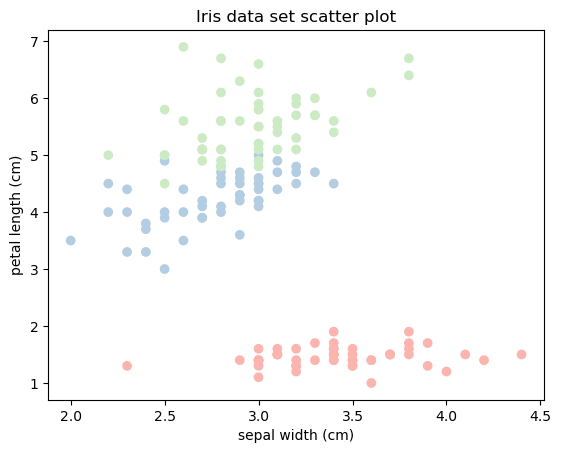

In [19]:
# Prepare a colourmap
cmap = np.array([
    plt.get_cmap('Pastel1').colors[0],
    plt.get_cmap('Pastel1').colors[1],
    plt.get_cmap('Pastel1').colors[2]
])
# Choose 2 features
chosen_features_index = [1, 2]
chosen_features_name = iris_feature_names[chosen_features_index]

# Get a subset of the data set with these two features
iris_X_chosen_features = iris_X[:, chosen_features_index]

# Plot the dataset using the 2 selected features
plt.scatter(
    iris_X_chosen_features[:, 0], iris_X_chosen_features[:, 1], c=cmap[iris_y])
plt.title('Iris data set scatter plot')
plt.xlabel(chosen_features_name[0])
plt.ylabel(chosen_features_name[1])
plt.show()

Now, we train a predictive model on the whole dataset using these two selected features. We will use this model to evaluate the quality and robustness of its predictions.

In [20]:
# Train a model
clf = fatf_models.KNN()
clf.fit(iris_X_chosen_features, iris_y)

We choose now one data point in a sparse region and another one in a dense region:

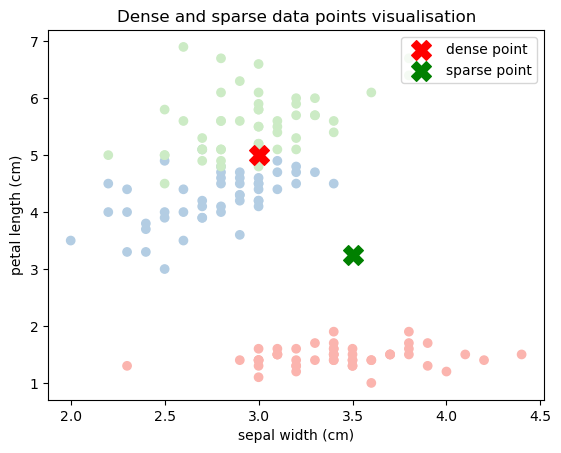

In [21]:
# Create two data points: one in a dense region and one in a sparse region
point_dense = np.array([[3.0, 5.0]])
point_sparse = np.array([[3.5, 3.25]])

# Plot the dense and sparse data points
plt.scatter(
    iris_X_chosen_features[:, 0], iris_X_chosen_features[:, 1], c=cmap[iris_y])
plt.scatter(
    point_dense[:, 0],
    point_dense[:, 1],
    c='r',
    s=200,
    marker='X',
    label='dense point')
plt.scatter(
    point_sparse[:, 0],
    point_sparse[:, 1],
    c='g',
    s=200,
    marker='X',
    label='sparse point')
plt.title('Dense and sparse data points visualisation')
plt.xlabel(chosen_features_name[0])
plt.ylabel(chosen_features_name[1])
plt.legend(loc='upper right')
plt.show()

Now, let us get the predictions for the two data points selected above.

The **dense** data point is of class: virginica (2).
The **sparse** data point is of class: versicolor (1).


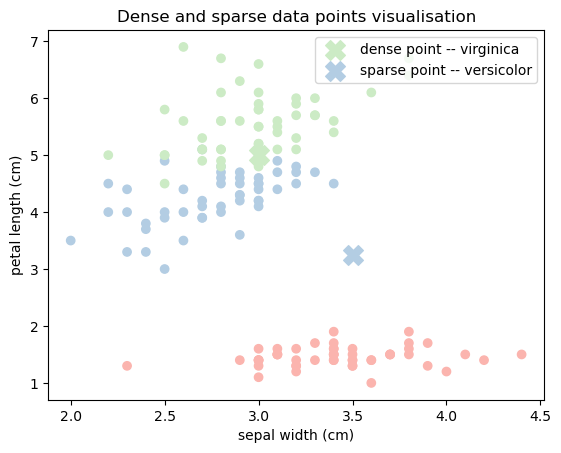

In [22]:
# Predict the two data points
point_dense_prediction = clf.predict(point_dense)[0]
point_sparse_prediction = clf.predict(point_sparse)[0]

# Print out the predictions...
print('The **dense** data point is of class: {} ({}).'.format(
    iris_class_names[point_dense_prediction], point_dense_prediction))
print('The **sparse** data point is of class: {} ({}).'.format(
    iris_class_names[point_sparse_prediction], point_sparse_prediction))

# ...and plot them with the class assignment
plt.scatter(
    iris_X_chosen_features[:, 0], iris_X_chosen_features[:, 1], c=cmap[iris_y])
plt.scatter(
    point_dense[:, 0],
    point_dense[:, 1],
    c=cmap[[int(point_dense_prediction)]],
    s=200,
    marker='X',
    label='dense point -- {}'.format(iris_class_names[point_dense_prediction]))
plt.scatter(
    point_sparse[:, 0],
    point_sparse[:, 1],
    c=cmap[[int(point_sparse_prediction)]],
    s=200,
    marker='X',
    label='sparse point -- {}'.format(
        iris_class_names[point_sparse_prediction]))
plt.title('Dense and sparse data points visualisation')
plt.xlabel(chosen_features_name[0])
plt.ylabel(chosen_features_name[1])
plt.legend(loc='upper right')
plt.show()

Now that we know where these two data points are located and what class is assigned to each of them by the classifier, we can see how a Data Density score can help us evaluate the quality and robustness of the predictions of the model:

In [23]:
# Print the class names for the probability vector
print('(The probability vector is based on the following class ordering: '
      '{}.)\n'.format(iris_class_names))

# Initialise a density estimator
iris_density = fatf_density.DensityCheck(iris_X_chosen_features)

# Get a denisty estimation for the dense point
density_score_dense = iris_density.score_data_point(point_dense[0, :])
# Get the probability predictions for the dense point
probabilities_dense = clf.predict_proba(point_dense)[0]

# Get a denisty estimation for the sparse point
density_score_sparse = iris_density.score_data_point(point_sparse[0, :])
# Get the probability predictions for the sparse point
probabilities_sparse = clf.predict_proba(point_sparse)[0]

print('The prediction probabilities for the sparse data point are: {}, with a '
      'density score of {}.'.format(probabilities_sparse,
                                    density_score_sparse))

print('The prediction probabilities for the dense data point are: {}, with a '
      'density score of {}.'.format(probabilities_dense, density_score_dense))

(The probability vector is based on the following class ordering: ['setosa' 'versicolor' 'virginica'].)

The prediction probabilities for the sparse data point are: [0. 1. 0.], with a density score of 0.9481604611988929.
The prediction probabilities for the dense data point are: [0.         0.33333333 0.66666667], with a density score of 0.10186747546117353.


### **Exercise 4**
* Check the API documentation and explain what the "density score" actually represents.

Given the previous results:
- Should we trust the model's output classifications? 
- Is there any difference in this regard between the dense and spare point classifications?

## Exercise 4 — Answers

### 1) What does the *density score* represent?
The *density score* is a **local data-density indicator** computed from **k-nearest neighbours**. Concretely, it uses the distance from a point to its **n-th closest neighbour** (where `neighbours = n`) as a proxy for how populated the surrounding region is:

- If the n-th neighbour is **close**, the area is **dense** (many nearby samples).
- If the n-th neighbour is **far**, the area is **sparse** (few similar samples nearby).

When `normalise_scores=True`, the resulting values are rescaled to **[0, 1]**, so they are easier to compare across points: values **near 0** correspond to **denser regions**, and values **near 1** correspond to **sparser regions**.

---

### 2) Given the previous results, should we trust the model’s classifications?
We should be cautious: the density score is a hint about whether the model is predicting in a **well-supported** region of the training data.

From the outputs:
- **Sparse point:** probabilities **[0, 1, 0]** with density score **≈ 0.948**.
- **Dense point:** probabilities **[0, 0.333, 0.667]** with density score **≈ 0.102**.

Even though the *sparse* point is classified with “full confidence” (all neighbours voting the same way in kNN), the **very high density score** suggests that those neighbours may actually be **far away**, i.e., the model is operating with limited local evidence. So, this prediction is **less trustworthy**.

For the *dense* point, the **low density score** indicates that there are many nearby samples supporting the decision region, so the prediction is generally **more grounded**—but the probabilities being split shows that it is likely close to a **decision boundary**, so certainty is still moderate.

---

### 3) Is there any difference between the dense and sparse point cases?
Yes:

- **Sparse point:** high confidence does **not** necessarily imply reliability here. The point lies in a **low-density** region (score close to 1), so the model may be extrapolating and the classification should be taken with extra care.
- **Dense point:** the point sits in a **high-density** region (score close to 0), so the prediction is supported by nearby data. However, the probability distribution is more ambiguous (2 vs 1 neighbour votes), which suggests that the point is near a class overlap/border and the classification is not fully certain.

In short: *sparse → less evidence (lower trust), dense → more evidence but possibly boundary uncertainty (medium trust).*

# **5. Experimenting with Aequitas**

Below, we show how to use the [Aequitas software](https://dssg.github.io/aequitas/) with the COMPAS dataset. COMPAS produces a risk score that predicts a person's likelihood of commiting a crime in the next two years. The output is a score between 1 and 10 that maps to low, medium or high. For the example here, we collapse this to a binary prediction. A score of 0 indicates a prediction of "low" risk according to COMPAS, while a 1 indicates "high" or "medium" risk.

The aim of this section is helping you understand how numbers in an Aequitas Bias Report are computed (see [https://github.com/dssg/aequitas/blob/master/docs/source/examples/compas_demo.ipynb](https://github.com/dssg/aequitas/blob/master/docs/source/examples/compas_demo.ipynb)).

In [24]:
# AEQUITAS
os.system("pip install aequitas==1.0.0")

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 40.0 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 1.8 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 486.0 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.4/795.4 kB 1.7 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 9.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

0

In [25]:
os.system("pip install numpy==1.24.4")

0

In [26]:
import pandas as pd
import seaborn as sns
from aequitas.audit import Audit
from aequitas.bias import Bias
from aequitas.fairness import Fairness
from aequitas.group import Group
import aequitas.plot as ap

We begin with loading the COMPAS dataset.

In [27]:
df = pd.read_csv("./testlib/COMPAS/compas_for_aequitas.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: './testlib/COMPAS/compas_for_aequitas.csv'

Below, you can see how data are distributed for some protected features (i.e., race, sex, and age). But also the assigned labels for low or high recedivism prediction.

In [ ]:
aq_palette = sns.diverging_palette(225, 35, n=2)
sns.set_theme(rc={'figure.figsize':(11.5,6.5)})

In [ ]:
by_race = sns.countplot(x="race", hue="score", data=df[df.race.isin(['African-American', 'Caucasian', 'Asian', 'Native American', 'Hispanic', 'Other'])], palette=aq_palette)

In [ ]:
label_by_race = sns.countplot(x="race", hue="label_value", data=df[df.race.isin(['African-American', 'Caucasian', 'Asian', 'Native American', 'Hispanic', 'Other'])], palette=aq_palette)

In [ ]:
by_sex = sns.countplot(x="sex", hue="score", data=df, palette=aq_palette)

In [ ]:
label_by_sex = sns.countplot(x="sex", hue="label_value", data=df, palette=aq_palette)

In [ ]:
by_age = sns.countplot(x="age_cat", hue="score", data=df, palette=aq_palette)

In [ ]:
label_by_age = sns.countplot(x="age_cat", hue="label_value", data=df, palette=aq_palette)

Now, we are to use Aequitas in three steps:

* Defining Groups
* Calculating Disparities
* Asseerting Fairness

Notice that Aequitas always requires a score column and requires a binary label_value column for supervised metrics, (e.g., False Discovery Rate - FDR, False Positive Rate - FPR, False Omission Rate - FOR, and False Negative Rate - FNR). Preprocessing includes but is not limited to checking for mandatory score and label_value columns as well as at least one column representing attributes specific to the data set. Moreover, Aequitas recognizes entity_id as a reserve column name and will not recognize it as an attribute column.

The following tables provide you with a legend to understand the results below.

#### Group Counts Calculated:

| Count Type | Column Name |
| --- | --- |
| False Positive Count | 'fp' |
| False Negative Count | 'fn' |
| True Negative Count | 'tn' |
| True Positive Count | 'tp' |
| Predicted Positive Count | 'pp' |
| Predicted Negative Count | 'pn' |
| Count of Negative Labels in Group | 'group_label_neg' |
| Count of Positive Labels in Group | 'group_label_pos' |
| Group Size | 'group_size'|
| Total Entities | 'total_entities' |

#### Absolute Metrics Calculated:

| Metric | Column Name |
| --- | --- |
| True Positive Rate | 'tpr' |
| True Negative Rate | 'tnr' |
| False Omission Rate | 'for' |
| False Discovery Rate | 'fdr' |
| False Positive Rate | 'fpr' |
| False Negative Rate | 'fnr' |
| Negative Predictive Value | 'npv' |
| Precision | 'precision' |
| Predicted Positive Ratio$_k$ | 'ppr' |
| Predicted Positive Ratio$_g$ | 'pprev' |
| Group Prevalence | 'prev' |

#### Disparities Calcuated:

| Metric | Column Name |
| --- | --- |
| True Positive Rate Disparity | 'tpr_disprity' |
| True Negative Rate | 'tnr_disparity' |
| False Omission Rate | 'for_disparity' |
| False Discovery Rate | 'fdr_disparity' |
| False Positive Rate | 'fpr_disparity' |
| False NegativeRate | 'fnr_disparity' |
| Negative Predictive Value | 'npv_disparity' |
| Precision Disparity | 'precision_disparity' |
| Predicted Positive Ratio$_k$ Disparity | 'ppr_disparity' |
| Predicted Positive Ratio$_g$ Disparity | 'pprev_disparity' |


In [ ]:
audit = Audit(df.drop(columns=["entity_id"]), label_column="label_value")
audit.audit()

In [ ]:
audit.confusion_matrix

In [ ]:
# we print results reounded with d decimal numbers
audit.metrics.round(3)

Let us compute disparities for the selected groups.

In [ ]:
auditd = Audit(df.drop(columns=["entity_id"]), label_column="label_value",
              reference_groups={'race':'Caucasian', 'sex':'Male', 'age_cat':'25 - 45'})

auditd.audit(bias_args={
    "alpha": 0.05,
    "check_significance": True,
    "mask_significance": True
})

auditd.disparity_df.style

The following table shows values for different disparity (always 1 for the reference groups: Caucasian, Male, 25-45). 

In [ ]:
auditd.disparities.style

We select the metrics (**fpr** stands for false positive rate, **fnr** stands for false negative rate, and **fdr** means false discovery rate) and set the disparity threshold.

In [ ]:
metrics = ['fpr','fnr','fdr']
disparity_tolerance = 1.25

**FPR** is tagged as **PREDICTIVE EQUALITY** in the plot below.

In [ ]:
auditd.summary_plot(metrics=metrics, fairness_threshold=disparity_tolerance)

Now we can check disparity for each selected attribute. For example, by race.

In [ ]:
bdf=auditd.disparity_df

The following function visualizes disparities across groups relative to a chosen reference. Arguments include the dataframe, sensitive attribute, reference group, metric, and tolerance threshold

In [ ]:
def plot_disparity(bdf, attribute_name, reference_group, metric_name,title=None,axvspan_range=1.25):
    """
    Disparity plot of a given metric with regard to its reference group.
    The axis is centered in the reference (1) and simetric.
    Arguments:
    bdf: DataFrame with columns 'attribute_name', 'attribute_value' and the metric we are interested in.
    attribute_name: sensitive attribute name (e.g., 'race').
    reference_group: reference group (e.g., 'Caucasian').
    metric_name: metric of interest (e.g, 'fnr').
    title: plot title.
    axvspan_range: acceptable range around the reference (in ‘times bigger/smaller’).
    """
    
    subset = bdf[bdf['attribute_name'] == attribute_name]
    groups = subset['attribute_value']
    metric_disparity = subset[metric_name]
    
    #Value for reference
    reference_metric = metric_disparity[groups == reference_group].iloc[0]
    
    #Ratio
    ratio = metric_disparity / reference_metric
    
    plot_x = np.where(
        ratio >= 1,
        np.log2(ratio), # times bigger: positive, this ansewrs the question how many times was the original ratio (the reference) duplicated?
        -np.log2(1 / ratio)# times smaller: negative
    )
    
    plot_data = pd.DataFrame({'groups': groups.values, 'x': plot_x})
    
    plt.figure(figsize=(14,3))
    sns.scatterplot(data=plot_data, x='x', y=[0]*len(plot_data), hue='groups', s=100)
    
    #Acceptable range around the refrence
    axvspan_left = -np.log2(axvspan_range)
    axvspan_right = np.log2(axvspan_range)
    plt.axvspan(axvspan_left, axvspan_right, color='green', alpha=0.2) #alpha is for opacity
    
    #Reference line
    plt.axvline(0, color='grey', linestyle='--')
    
    #Limits for x
    limit = max(abs(plot_x)) * 1.2
    plt.xlim(-limit, limit)
    
    max_tick = int(np.ceil(limit)) #ceil rounds up to the ccealing
    ticks = np.arange(-max_tick, max_tick + 1)
    tick_labels = [f"{2**abs(tick):.0f}" for tick in ticks]
    plt.xticks(ticks, tick_labels, rotation=45)
    
    #Notations
    plt.text(0.01, 1.02, 'Times Smaller', transform=plt.gca().transAxes,ha='left', va='bottom', fontsize=12) #transAxes to fix the text
    plt.text(0.99, 1.02, 'Times Larger', transform=plt.gca().transAxes,ha='right', va='bottom', fontsize=12)
    plt.text(0, 0.105, 'EQUAL', ha='center', fontsize=11)
    plt.ylim(-0.1, 0.1)
    plt.yticks([])
    plt.xlabel('Times bigger / smaller relative to reference', labelpad=20)
    plt.ylabel(metric_name.upper())
    plt.title(title if title else f'Disparities on {attribute_name}', fontsize=15, pad=20)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
plot_disparity(bdf, 'race', 'Caucasian', 'fpr','Disparities on race', 1.25)

In [ ]:
plot_disparity(bdf, 'race', 'Caucasian', 'fnr','Disparities on race', 1.25)

In [ ]:
plot_disparity(bdf, 'race', 'Caucasian', 'fdr','Disparities on race', 1.25)

Below we see disparity values for Sex and Age.

In [ ]:
plot_disparity(bdf, 'sex', 'Male', 'fpr','Disparities on Sex', 1.25)

In [ ]:
plot_disparity(bdf, 'sex', 'Male', 'fnr','Disparities on race', 1.25)

In [ ]:
plot_disparity(bdf, 'sex', 'Male', 'fdr','Disparities on race', 1.25)

In [ ]:
plot_disparity(bdf, 'age_cat', '25 - 45', 'fpr','Disparities on Age', 1.25)

In [ ]:
plot_disparity(bdf, 'age_cat', '25 - 45', 'fnr','Disparities on Age', 1.25)

In [ ]:
plot_disparity(bdf, 'age_cat', '25 - 45', 'fdr','Disparities on Age', 1.25)

**Let us see below how to visualize disparities and how to interpret parities**

In [ ]:
b=Bias(df)
g=Group(df)
f = Fairness()
fdf = f.get_group_value_fairness(bdf)

In [ ]:
parity_detrminations = f.list_parities(fdf)
absolute_metrics = g.list_absolute_metrics(fdf)
fdf[['attribute_name', 'attribute_value'] + absolute_metrics + b.list_disparities(fdf) + parity_detrminations].style

By construction, the base reference groups (Caucasian for race, Male for gender, and 25-45 for age_cat) have supervised fairness (i.e., the disparity ratio is 1 for all metrics). In addition, only the Hispanic group exhibits also supervised fairness (pay attention to *for_disparity equals 1*).

It is worth noting that the African-Americans are roughly twice as likely to have false positives as Caucasian (1.91 versus 1.0) and 40 percent less likely to false negatives (0.58 versus 1.0). In real terms, 44.8% of African-Americans who did not recidivate were marked high or medium risk (with potential for associated penalties), compared with 23.4% of Caucasian non-reoffenders. This is unfair.

With the following table we see which pairs group-metric pass the parity test. For a group to pass the parity test its disparity to the reference group must be below the threshold for all attributes and the selected metrics.

In [ ]:
gaf = f.get_group_attribute_fairness(fdf)
gaf

### **Exercise 5.a**

A court uses COMPAS to assist in parole decisions.
As you have seen, results from Aequitas' analysis show racial disparities in the calculated metrics.
The judge requests a specific recommendation based on quantitative evidence. Your task is to analyze group-level outcomes and make a justified decision on which metric to prioritize when setting a decision threshold.

Using the fdf table obtained from Aequitas extract the absolute values of FPR and FNR for groups African-American and Caucasian of the protected attribute race.

The judge doesn't understand technical terms like FPR and FNR and wants a simple recommendation.

- Explain in plain language what it means to be a false positive (FP) and a false negative (FN) in the context of COMPAS predicting recidivism.
- Overall, considering both FPR and FNR, which group experiences the greater unfairness in the current predictions?
- Suppose you have to choose only one metric (FPR or FNR) to ensure parity across racial groups. Which one would you select and why?
- In the context of colon cancer prediction, what does it mean to be a false positive (FP) and a false negative (FN)? In this case, what would be the most critical metric?

We have seen that some groups are more vulnerable than others. It is possible that combining these attributes may reveal new inequities that are not detected when each variable is considered separately.
- Create a new column that combines the sex and age variables.
- Perform an Aequitas audit using this new column as the protected attribute.
- For 'fpr', 'fnr' and 'fdr' print the disparities and reflect: do new inequities appear within these combined groups? (Use summary_plot and disparity_plot)

Answer the following questions:
-  If we only had information about the sex attribute for 'fpr' and 'fnr', does the sex_age attribute add new nuances?
-  What if we only had information about the age attribute?
-  What can you observe for the 'fdr' metric? Are there any new disparities?

### **Exercise 5.b**

The adult dataset is used to predict whether income exceeds $50K/yr based on census data. Load the adult for aequitas dataset you can find in the folder ADULT in testlib.
- Use Aequitas to audit this new dataset and obtain the disparities for the sensitive attributes gender, work_cat and age_cat as we've seen before. (Metrics: 'fpr', 'fnr' and 'fdr' | disparity_tolerance =1.25). Summarise it all in a summary plot.
- What disparities can you observe?

** Note: Do not be alarmed by the RuntimeWarning message. It appears because the model is so inaccurate with some groups (such as women) that it has zero correct predictions. 
Without variety in the data for that group, the mathematical calculations become unstable. This is a warning about the model's bias, not an error in your code.

We've seen above that combining attributes may reveal new inequities. Combine the sensitive attributes gender and age in a new attribute.
Audit the new dataset and get the summary plot with the same metrics and disparity tolerance as before.
- What can you observe for this new feature?
- Why is it not possible to calculate the relative disparity for some subgroups? What should be tuned to be able to calculate these diparities?
- If we were to tweak this metric, what possible implications would it have for the overall accuracy of the model?

**Note: Do not be concerned if you see NaN values in the FDR (False Discovery Rate) metric. This occurs when the model does not make any positive predictions for that group (pp column = 0). 
As there are no positive predictions, the mathematical calculation of the ratio cannot be performed. In such cases, consult the FPR column to understand the behaviour of the model.